In [23]:
import numpy as np
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals


Setup

In [24]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
n_trials = 1000
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2025-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
# atr_multiplier = 3  # atr multiplier for chandelier exit
# adx_threshold = 25  # trend strength
# ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)
# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close']/(df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))


                                   close       equity
2025-09-28 12:00:00+00:00  110011.101562  1175.017212
2025-09-28 16:00:00+00:00  110353.203125  1178.671143
2025-09-28 20:00:00+00:00  112127.796875  1197.625366
2025-09-29 00:00:00+00:00  111862.500000  1194.791748
2025-09-29 04:00:00+00:00  111863.601562  1194.803467
2025-09-29 08:00:00+00:00  112093.398438  1197.257935
2025-09-29 12:00:00+00:00  113844.000000  1215.955933
2025-09-29 16:00:00+00:00  114358.296875  1221.449097
2025-09-29 20:00:00+00:00  114365.203125  1221.522827
2025-09-30 00:00:00+00:00  114430.601562  1222.221313


Optuna setup

In [25]:
def objective(trial: optuna.Trial):

    # Entry
    adx_threshold = trial.suggest_int("adx_threshold", 0, 20)
    adx_length = trial.suggest_int("adx_length", 0, 20)
    # sar_acceleration = trial.suggest_float("sar_acceleration", 0.01, 0.05, step=0.01)
    # sar_maximum = trial.suggest_float("sar_maximum", 0.05, 0.2, step=0.01)

    # Exit
    atr_multiplier = trial.suggest_float("atr_multiplier", .1, 3, step=0.1)
    ce_low_length = trial.suggest_int("ce_low_length", 0, 10)
    # ce_high_length = trial.suggest_int("ce_high_length", 1, 30)
    # atr_length = trial.suggest_int("atr_length", 1, 30)

    s = Signals(adx_threshold=adx_threshold,
                adx_length=adx_length,
                atr_multiplier=atr_multiplier,
                # atr_length=atr_length,
                # ce_high_length=ce_high_length,
                ce_low_length=ce_low_length,
                # sar_acceleration=sar_acceleration,
                # sar_maximum=sar_maximum,
                )

    signals = s.calc_signals(df.copy())
    bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee,start_equity=start_equity)
    stats, profit_df = bt.run()

    sortino = stats['sortino']
    return sortino

sampler = RandomSampler(seed=42)  # optional seed for reproducibility
sampler2 = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)

[I 2025-11-07 00:13:16,551] A new study created in memory with name: no-name-da62396a-0469-48c3-91e6-71dc141f9cb8
[I 2025-11-07 00:13:16,612] Trial 0 finished with value: 4.72024017282425 and parameters: {'adx_threshold': 7, 'adx_length': 19, 'atr_multiplier': 2.2, 'ce_low_length': 6}. Best is trial 0 with value: 4.72024017282425.
[I 2025-11-07 00:13:16,672] Trial 1 finished with value: 2.484046371650345 and parameters: {'adx_threshold': 3, 'adx_length': 3, 'atr_multiplier': 0.2, 'ce_low_length': 9}. Best is trial 0 with value: 4.72024017282425.
[I 2025-11-07 00:13:16,737] Trial 2 finished with value: 2.3539730525000917 and parameters: {'adx_threshold': 12, 'adx_length': 14, 'atr_multiplier': 0.1, 'ce_low_length': 10}. Best is trial 0 with value: 4.72024017282425.
[I 2025-11-07 00:13:16,801] Trial 3 finished with value: 5.2764621913779 and parameters: {'adx_threshold': 17, 'adx_length': 4, 'atr_multiplier': 0.6, 'ce_low_length': 2}. Best is trial 3 with value: 5.2764621913779.
[I 2025-

Study Results

In [26]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start','datetime_complete','duration','state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))


|   number |     value |   adx_length |   adx_threshold |   atr_multiplier |   ce_low_length |
|----------|-----------|--------------|-----------------|------------------|-----------------|
|      166 | 17.8119   |            3 |               2 |              0.8 |               1 |
|      266 | 16.2381   |           15 |               8 |              0.8 |               1 |
|      279 | 15.9957   |           18 |               1 |              0.8 |               1 |
|       27 | 15.528    |            1 |               4 |              0.9 |               1 |
|      649 | 14.5842   |           10 |               5 |              0.9 |               1 |
|      880 | 14.3477   |            9 |               4 |              0.9 |               1 |
|      430 | 13.0373   |            2 |               2 |              1   |               1 |
|      273 | 12.9546   |           10 |              12 |              0.7 |               1 |
|      883 | 12.8741   |            6 |           

In [27]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sortino: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sortino: 17.81 
|----------------|-----|
| adx_threshold  | 2   |
| adx_length     | 3   |
| atr_multiplier | 0.8 |
| ce_low_length  | 1   |


Visualization

In [28]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
show(fig2)



From the slice plot can notice a few things...

- looks like a lowish ce_low_length value is ideal All sortino values > 8 are ce_low_length = 1
- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6
- ADX_length and ADX_threshold appear to perform better at low values

Generally there aren't major correlations, but can generally see where there might be better results.  The slice plot does slightly agree with the most hyperparameter importance, since these are the only values that so some sort of correlation to sortino ratio.


NOTE:  Removed atr_length and ce_high_length from the slice plot, since they have very little correlation to sortino ratio.


In [29]:
# fig4 = optuna.visualization.plot_contour(study)
# fig4.update_layout(height=1000)
# for trace in fig4.data:
#     if hasattr(trace, "marker"):
#         # ensure markers are visible when mode exists
#         if hasattr(trace, "mode") and trace.mode and "markers" not in str(trace.mode):
#             trace.mode = f"{trace.mode}+markers"
#         trace.marker.size = 1
# show(fig4)

fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

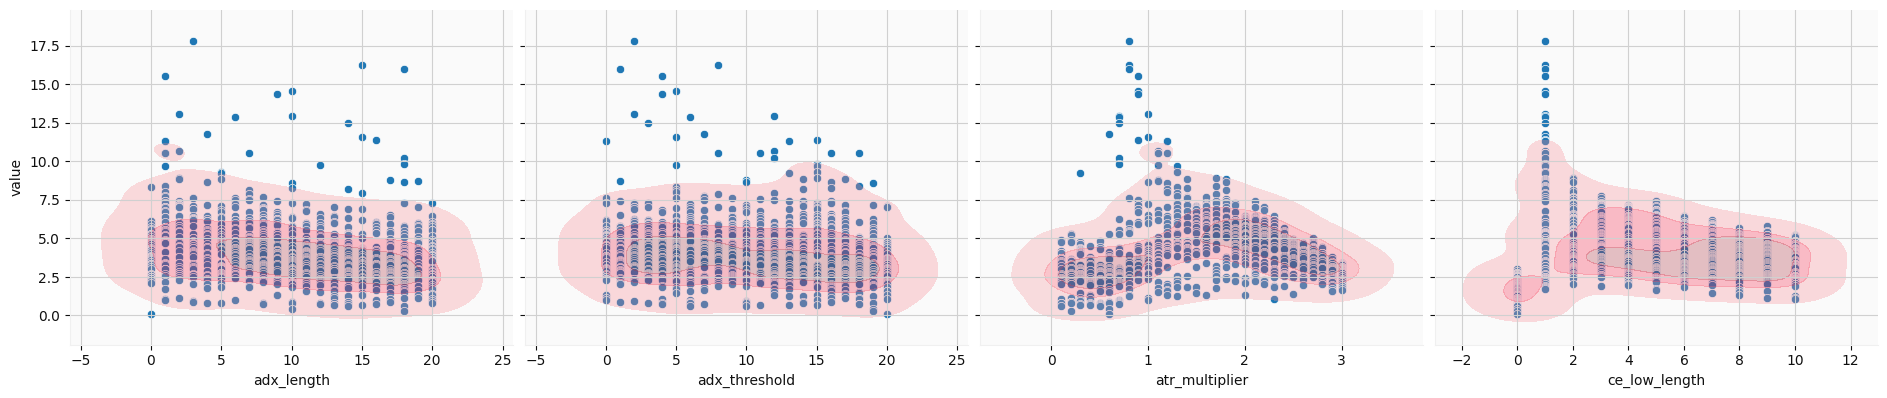

In [30]:
g = sns.pairplot(data=trials,
                 x_vars=trials.columns[2:],
                 y_vars=trials.columns[1],
                 height=4.0,
                 aspect=1.2,

                 )
g.map(sns.kdeplot, levels=4, color='crimson',  fill=True,  alpha=0.3)

plt.show()

Best Trial Backtest

In [31]:
adx_threshold = best_params['adx_threshold']
adx_length = best_params['adx_length']
atr_multiplier = best_params['atr_multiplier']
# atr_length = best_params['atr_length']
# ce_high_length = best_params['ce_high_length']
ce_low_length = best_params['ce_low_length']
# sar_acceleration = best_params['sar_acceleration']
# sar_maximum = best_params['sar_maximum']


s = Signals(adx_threshold=adx_threshold,
            adx_length=adx_length,
            atr_multiplier=atr_multiplier,
            # atr_length=atr_length,
            # ce_high_length=ce_high_length,
            ce_low_length=ce_low_length,
            # sar_acceleration=sar_acceleration,
            # sar_maximum=sar_maximum,
            )
signals = s.calc_signals(df.copy())
bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee)
stats, profit_df = bt.run()
print(f"\n Stats")
print(tabulate(stats.items(), tablefmt="github"))
print(f"\n Profit DataFrame")
print(profit_df.tail().to_string())


 Stats
|------------------|------------|
| trading_days     |  272       |
| total_profit     | 2009.18    |
| total_profit_pct |  200.918   |
| sharpe           |    6.39748 |
| sortino          |   17.8119  |
| wins             |   69       |
| losses           |    7       |
| win_rate         |   90.7895  |

 Profit DataFrame
                           Entry_Price  Exit_Price          close   Returns  Window_Profit       Equity
2025-09-29 08:00:00+00:00          0.0         0.0  112093.398438  0.002054            NaN  2947.715683
2025-09-29 12:00:00+00:00          0.0         0.0  113844.000000  0.015617            NaN  2993.751183
2025-09-29 16:00:00+00:00          0.0         0.0  114358.296875  0.004518            NaN  3007.275628
2025-09-29 20:00:00+00:00          0.0         0.0  114365.203125  0.000060            NaN  3007.457241
2025-09-30 00:00:00+00:00          0.0         0.0  114430.601562  0.000572       0.033632  3009.177021


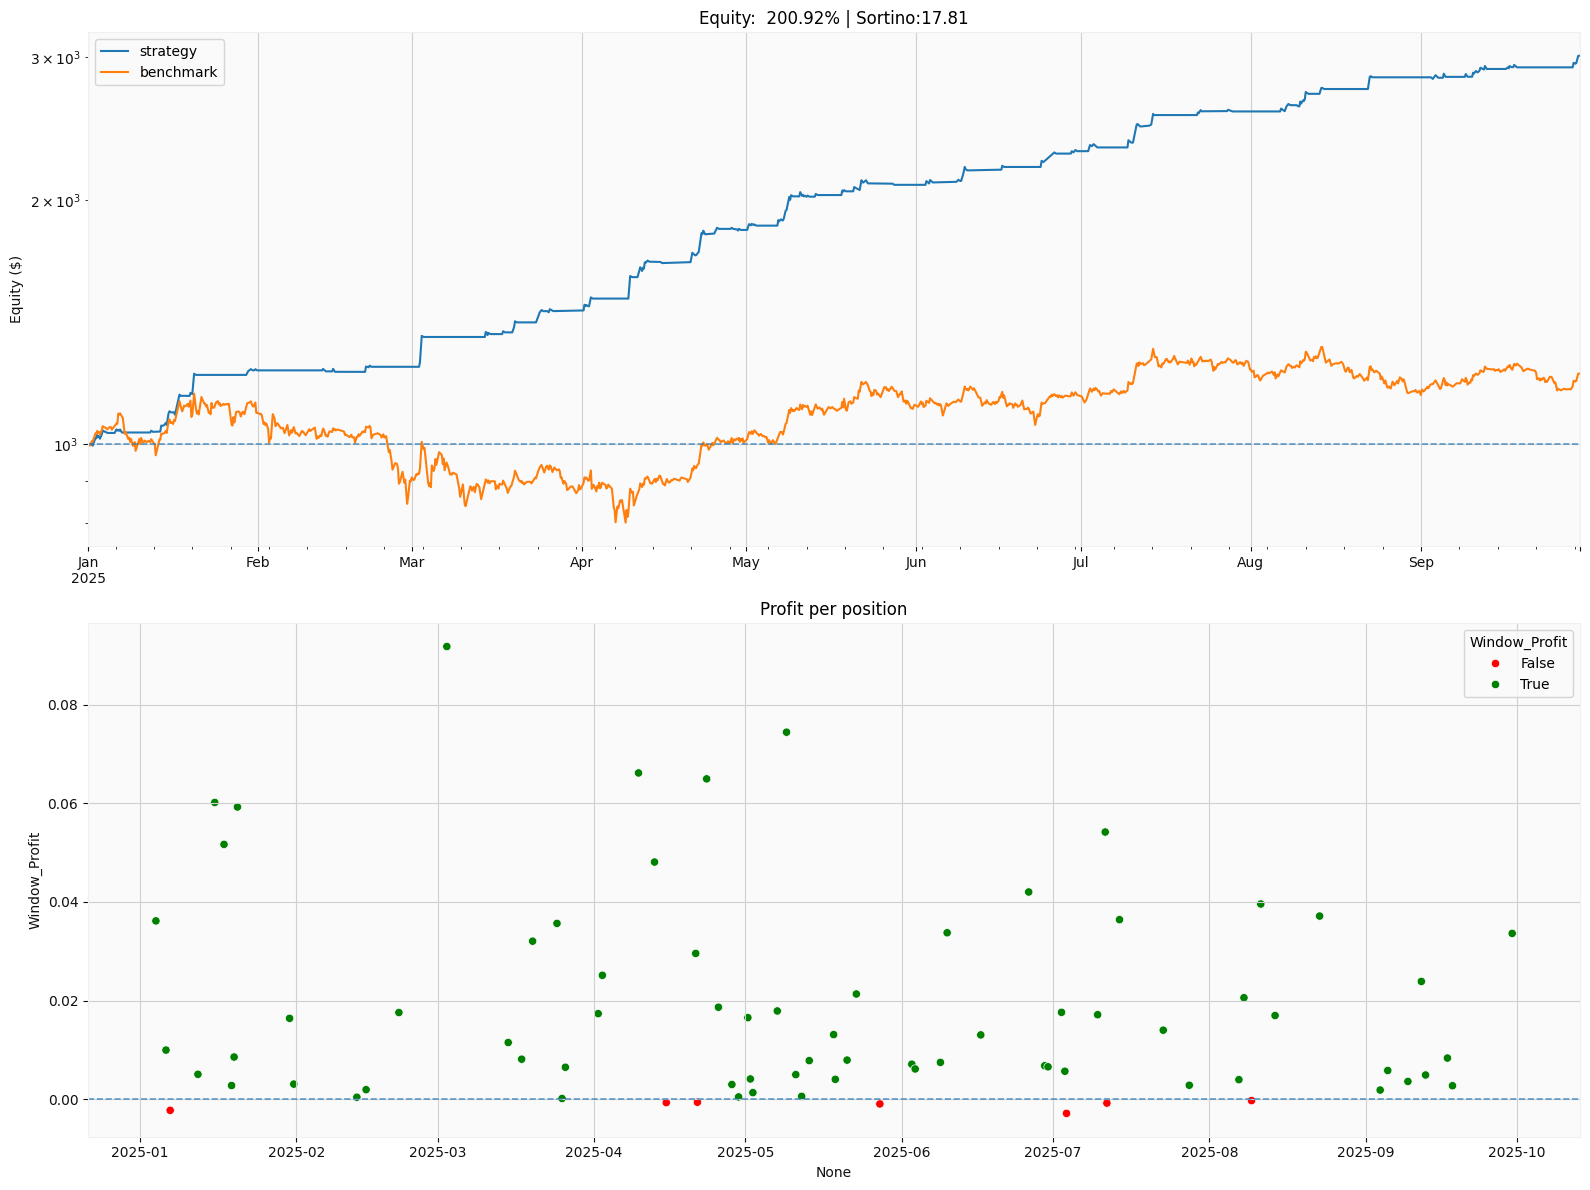

In [32]:
# plots
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
profit_df['Equity'].plot(ax=axes[0], title=f'Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{best_value:.2f}',label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
sns.scatterplot(x=profit_df.index, y='Window_Profit', data=profit_df, ax=axes[1], hue=profit_df['Window_Profit']>0, palette={True: 'green', False: 'red'})
axes[1].set_title('Profit per position')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
plt.tight_layout()
plt.show()

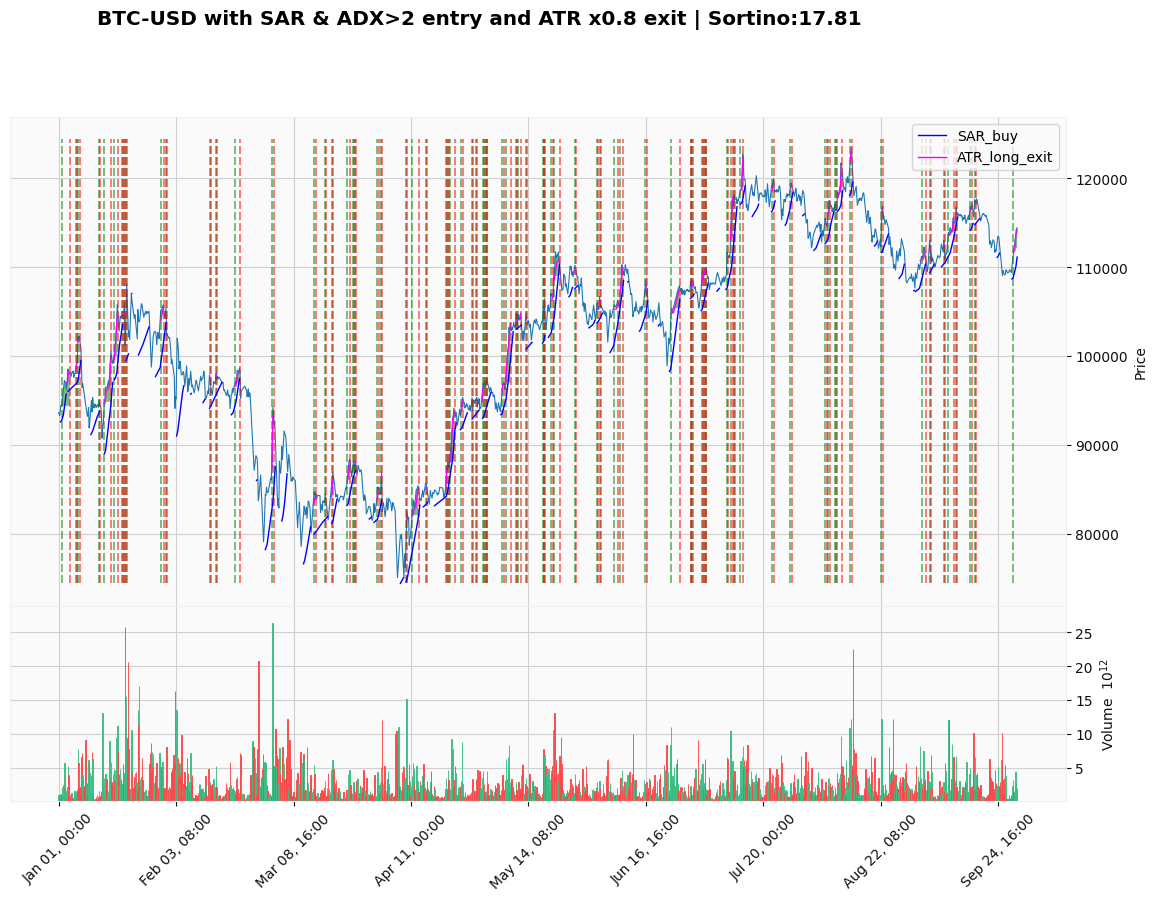

In [33]:
# Combine and color differently
##  Boolean where in position

y1_arr = signals['close'].values
filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']
in_position = signals['in_position']

y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]
# Build sorted timestamps with colors (keeps colors aligned with dates)
entries = [(ts, 'g') for ts in filtered_entry[filtered_entry].index]
exits   = [(ts, 'r') for ts in filtered_exit[filtered_exit].index]
pairs = sorted(entries + exits, key=lambda x: x[0])

# Extract in order expected by mplfinance
vline_dates  = [ts for ts, _ in pairs]
vline_colors = [c  for _,  c in pairs]

adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),


]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 12),
    figscale=1.7,
    tight_layout=False,
    title=f"{symbols[0]}-USD with SAR & ADX>{adx_threshold} entry and ATR x{atr_multiplier:.1f} exit | Sortino:{best_value:.2f}",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)